# Role Coordination Game V2

This notebook implements a cooperative multi-agent role coordination game where three players must coordinate to defeat an enemy by adopting complementary roles (Fighter, Tank, Healer).

## Overview

**Key Features:**
- **Bayesian Role Inference**: Players use probabilistic inference to deduce each other's roles from observed actions
- **Dynamic Enemy Health**: Enemy health changes based on team composition and actions
- **Utility-Based Role Assignment**: Player stats influence role suitability
- **Multiple Variants**: Compare unique vs non-unique role constraints, basic vs enhanced combat systems

**Game Mechanics:**
- 3 Players must coordinate roles: Fighter (damage), Tank (defense), Healer (support)
- Enemy health progresses through 5 states: CRITICAL → LOW → MEDIUM → HIGH → FULL
- Team wins by reducing enemy health to CRITICAL
- Players infer roles through Bayesian updating based on observed actions


## 1. Imports and Setup


In [95]:
from memo import memo
import jax
import jax.numpy as np
from enum import IntEnum, auto
import random



## 2. Game Definition

This section defines the core game mechanics:
- **Roles**: Fighter, Tank, Healer (each has different action preferences)
- **Actions**: Attack, Defend, Heal
- **Enemy Health States**: CRITICAL, LOW, MEDIUM, HIGH, FULL
- **Role Policies**: Probability distributions over actions given role and enemy health
- **Transition Function**: How enemy health changes based on number of attackers
- **Player Stats**: Each player has STR/DEF/SUP stats that influence role suitability


In [96]:
class Role(IntEnum): Fighter = 0; Tank = 1; Healer = 2
class Action(IntEnum): Attack = 0; Defend = 1; Heal = 2
class EnemyHealth(IntEnum): CRITICAL = 0; LOW = 1; MEDIUM = 2; HIGH = 3; FULL = 4

# State is the enemy's health discretized into 5 levels: CRITICAL, LOW, MEDIUM, HIGH, FULL
# Actions: Attack (damage enemy), Defend (protect team), Heal (support team)
# Transition depends on how many players attack vs enemy's random healing

# ROLE_ACTION_STATE_PROBS[role, enemy_health, action]
# Probabilities: P(action | role, enemy_health)
# Made LESS discriminative to slow convergence - roles are less "pure"
ROLE_ACTION_STATE_PROBS = np.array([
    # Fighter probabilities [enemy_health, action]
    [
        [0.60, 0.25, 0.15],  # CRITICAL: attack more (60% attack, 25% defend, 15% heal)
        [0.55, 0.30, 0.15],  # LOW: still attacking (55% attack)
        [0.50, 0.35, 0.15],  # MEDIUM: balanced attacker (50% attack)
        [0.50, 0.35, 0.15],  # HIGH: more cautious (50% attack)
        [0.45, 0.40, 0.15],  # FULL: most cautious (45% attack, 40% defend)
    ],
    # Tank probabilities [enemy_health, action]
    [
        [0.25, 0.60, 0.15],  # CRITICAL: still defend (60% defend)
        [0.25, 0.55, 0.20],  # LOW: defend (55% defend, 20% heal)
        [0.20, 0.55, 0.25],  # MEDIUM: balanced defender (55% defend)
        [0.15, 0.60, 0.25],  # HIGH: defend more (60% defend)
        [0.10, 0.65, 0.25],  # FULL: defend heavily (65% defend)
    ],
    # Healer probabilities [enemy_health, action]
    [
        [0.25, 0.15, 0.60],  # CRITICAL: support team (60% heal)
        [0.20, 0.20, 0.60],  # LOW: mostly heal (60% heal)
        [0.20, 0.20, 0.60],  # MEDIUM: heal (60% heal)
        [0.15, 0.20, 0.65],  # HIGH: heal more (65% heal)
        [0.10, 0.20, 0.70],  # FULL: heal heavily (70% heal)
    ],
])

@jax.jit
def role_policy(role, action, enemy_health):  # role-conditioned action likelihood P(action | role, enemy_health)
    return ROLE_ACTION_STATE_PROBS[role, enemy_health, action]

# Transition probability matrix [num_attackers, change_type]
# change_type: 0 = decrease health, 1 = stay same, 2 = increase health (enemy heals)
# REBALANCED: 1-2 attackers more effective, boss less regenerative
TRANSITION_PROBS = np.array([
    [0.0, 0.20, 0.80],   # 0 attackers: 80% heal (reduced from 85%)
    [0.35, 0.55, 0.10],  # 1 attacker: 35% damage! (buffed from 20%, heal nerfed from 30% to 10%)
    [0.55, 0.35, 0.10],  # 2 attackers: 55% damage (buffed from 45%)
    [0.75, 0.20, 0.05],  # 3 attackers: 75% damage (buffed from 70%)
])

@jax.jit
def Transition(current_enemy_health, num_attackers, key):
    """
    Update enemy health state based on number of attackers.
    
    Args:
        current_enemy_health: Current enemy health state (0=CRITICAL to 4=FULL)
        num_attackers: Number of players attacking (0-3)
        key: JAX random key for stochasticity
    
    Returns:
        next_enemy_health: Updated enemy health state
    
    Transition logic:
    - Boss is difficult but can be beaten with 1-2 attackers
    - More attackers -> higher chance enemy loses health
    - 1 attacker: 35% damage chance (viable for balanced teams)
    - 2+ attackers: Much more effective
    - Enemy can't go below CRITICAL or above FULL
    """
    
    # Clamp num_attackers to valid range
    num_attackers = np.clip(num_attackers, 0, 3)
    
    # Get probabilities based on number of attackers
    probs = TRANSITION_PROBS[num_attackers]
    
    # Sample the change (-1, 0, +1)
    change = jax.random.choice(key, np.array([-1, 0, 1]), p=probs)
    
    # Apply change with bounds
    next_health = np.clip(current_enemy_health + change, 0, 4)
    
    return next_health

# Player Stats System
# Each player has three stats: Strength (ATK), Defense (DEF), Support (SUP)
# Stats are normalized to sum to 1.0 for each player

def generate_player_stats(player_id, seed=42):
    """
    Generate random player stats.
    Each player has 3 stats that sum to 1.0: Strength, Defense, Support
    
    Args:
        player_id: ID of player (0, 1, or 2)
        seed: Random seed
    
    Returns:
        stats: [strength, defense, support] that sum to 1.0
    """
    random.seed(seed + player_id)
    # Sample from Dirichlet distribution for stats that sum to 1
    alpha = [1.0, 1.0, 1.0]  # Uniform prior over stats
    raw_stats = [random.gammavariate(a, 1.0) for a in alpha]
    total = sum(raw_stats)
    stats = [s / total for s in raw_stats]
    return np.array(stats)

def compute_role_utility(player_stats, role):
    """
    Compute utility of a role for a player based on their stats.
    
    Args:
        player_stats: [strength, defense, support]
        role: Role enum (Fighter=0, Tank=1, Healer=2)
    
    Returns:
        utility: How well-suited this player is for this role
    """
    # Role preferences:
    # Fighter: prefers high strength
    # Tank: prefers high defense
    # Healer: prefers high support
    if role == Role.Fighter:
        return player_stats[0]  # strength
    elif role == Role.Tank:
        return player_stats[1]  # defense
    else:  # Healer
        return player_stats[2]  # support

def create_utility_based_prior(player_stats_list, temperature=1.0, allow_duplicates=False):
    """
    Create role prior based on player stats.
    Higher utility for a role = higher prior probability.
    
    Args:
        player_stats_list: List of 3 player stat arrays [[str, def, sup], ...]
        temperature: Controls sharpness (lower = more deterministic)
        allow_duplicates: If True, allow multiple players to have the same role
    
    Returns:
        prior: 3x3x3 array of P(r0, r1, r2 | stats)
    """
    prior = np.zeros((3, 3, 3))
    
    for r0 in range(3):
        for r1 in range(3):
            for r2 in range(3):
                # Skip if roles are not unique (unless duplicates allowed)
                if not allow_duplicates:
                    if r0 == r1 or r0 == r2 or r1 == r2:
                        continue
                
                # Compute utility for each player in their assigned role
                u0 = compute_role_utility(player_stats_list[0], r0)
                u1 = compute_role_utility(player_stats_list[1], r1)
                u2 = compute_role_utility(player_stats_list[2], r2)
                
                # Total utility (multiplicative for simplicity)
                # Apply temperature: lower temp = sharper distribution
                utility = np.exp((u0 + u1 + u2) / temperature)
                prior = prior.at[r0, r1, r2].set(utility)
    
    # Normalize to get probability distribution
    prior = prior / np.sum(prior)
    
    return prior

@jax.jit
def get_element(array, i0, i1, i2):
    return array[i0, i1, i2]



## 3. Role Inference Model

The core inference mechanism using the `memo` probabilistic programming framework. Players observe each other's actions and update their beliefs about role assignments using Bayesian inference.

**Key Function**: `role_inference()` - Updates role probability distribution given observed actions and enemy health state.


In [97]:
@memo
def role_inference[r0 : Role, r1 : Role, r2 : Role](role_prior, obs_a0, obs_a1, obs_a2, enemy_health):
    observer: knows(r0, r1, r2) # Push array axis variables into observer's frame
    observer: thinks[
        team: assigned(r0 in Role, r1 in Role, r2 in Role, wpp=get_element(role_prior, r0, r1, r2)), # Assign roles to each player
        team: chooses(a0 in Action, wpp=role_policy(r0, a0, enemy_health)), # Choose player 0's action (a0) according to their role (r0)
        team: chooses(a1 in Action, wpp=role_policy(r1, a1, enemy_health)), # Choose player 1's action (a1) according to their role (r1)
        team: chooses(a2 in Action, wpp=role_policy(r2, a2, enemy_health))  # Choose player 2's action (a2) according to their role (r2)
    ]
    observer: observes_that [team.a0 == obs_a0] # Observe player 0's action
    observer: observes_that [team.a1 == obs_a1] # Observe player 1's action
    observer: observes_that [team.a2 == obs_a2] # Observe player 2's action
    return observer[Pr[r0 == team.r0 and r1 == team.r1 and r2 == team.r2]]




## 4. Simulation Framework

Functions to simulate the coordination game over multiple timesteps:
- **`marginalize()`**: Extract single-agent role beliefs from joint distribution
- **`simulate_role_convergence()`**: Run full simulation with role inference and enemy health dynamics
- **`create_utility_based_prior()`**: Initialize role beliefs based on player stats


In [98]:
import random

def marginalize(role_probs, agent_idx):
    """Marginalize role probabilities to get distribution for a single agent."""
    if agent_idx == 0:
        return np.sum(role_probs, axis=(1, 2))
    elif agent_idx == 1:
        return np.sum(role_probs, axis=(0, 2))
    else:  # agent_idx == 2
        return np.sum(role_probs, axis=(0, 1))

def simulate_role_convergence(n_steps, player_stats_list, initial_enemy_health=EnemyHealth.FULL, 
                               seed=42, temperature=1.0):
    """
    Simulate the role coordination game with enemy health dynamics.
    Stops when enemy reaches CRITICAL health (death) or max steps reached.
    
    Args:
        n_steps: Maximum number of timesteps to simulate
        player_stats_list: List of 3 player stat arrays [[str, def, sup], ...]
        initial_enemy_health: Starting enemy health state
        seed: Random seed for reproducibility
        temperature: Temperature for utility-based prior (lower = sharper)
    
    Returns:
        role_history: History of sampled roles [actual_steps x 3]
        action_history: History of sampled actions [actual_steps x 3]
        role_prob_history: History of role beliefs [actual_steps x 3x3x3]
        enemy_health_history: History of enemy health states [actual_steps + 1] (includes final state)
        actual_steps: Actual number of action steps taken
        victory: Whether the enemy was defeated
        role_prior: Initial utility-based prior used
    """
    random.seed(seed)
    key = jax.random.PRNGKey(seed)
    
    # Create utility-based prior from player stats
    role_prior = create_utility_based_prior(player_stats_list, temperature=temperature)
    role_probs = role_prior
    enemy_health = initial_enemy_health
    
    # Preallocate arrays for histories
    role_history = np.zeros((n_steps, 3), dtype=np.int32)
    action_history = np.zeros((n_steps, 3), dtype=np.int32)
    role_prob_history = np.zeros((n_steps, 3, 3, 3), dtype=np.float32)
    enemy_health_history = np.zeros(n_steps + 1, dtype=np.int32)  # +1 to store final state
    
    # Store initial enemy health
    enemy_health_history = enemy_health_history.at[0].set(enemy_health)
    
    for t in range(n_steps):
        # Sample a role for each agent according to the marginal distribution over their role
        roles = [random.choices([0, 1, 2], weights=marginalize(role_probs, i))[0] for i in range(3)]
        role_history = role_history.at[t].set(np.array(roles))  # Store roles

        # Sample an action for each agent according to the role policy conditioned on enemy health
        actions = [random.choices([0, 1, 2], weights=ROLE_ACTION_STATE_PROBS[r, enemy_health, :])[0] for r in roles]
        action_history = action_history.at[t].set(np.array(actions))  # Store actions

        # Update (common) beliefs about role assignments via role inference
        role_probs = role_inference(role_probs, *actions, enemy_health=enemy_health)
        role_prob_history = role_prob_history.at[t].set(role_probs)  # Store updated probabilities
        
        # Count number of attackers (Action.Attack == 0)
        num_attackers = sum(1 for a in actions if a == Action.Attack)
        
        # Update enemy health using Transition function
        key, subkey = jax.random.split(key)
        enemy_health = Transition(enemy_health, num_attackers, subkey)
        
        # Store new enemy health (at position t+1)
        enemy_health_history = enemy_health_history.at[t + 1].set(enemy_health)
        
        # Check if enemy is dead (CRITICAL = 0) AFTER the transition
        if enemy_health == EnemyHealth.CRITICAL:
            print(f"\n🎉 Victory! Enemy defeated at step {t + 1}!")
            actual_steps = t + 1
            victory = True
            break
    else:
        # Loop completed without break - enemy survived all steps
        actual_steps = n_steps
        victory = False
        print(f"\n💀 Defeat! Enemy survived {n_steps} steps with {EnemyHealth(enemy_health).name} health remaining.")

    # Trim arrays to actual length
    role_history = role_history[:actual_steps]
    action_history = action_history[:actual_steps]
    role_prob_history = role_prob_history[:actual_steps]
    enemy_health_history = enemy_health_history[:actual_steps + 1]  # +1 to include final state

    return role_history, action_history, role_prob_history, enemy_health_history, actual_steps, victory, role_prior




## 5. Basic Simulation Run

Run a single simulation with the basic game mechanics and visualize role convergence.


PLAYER STATS
Player 0: STR=0.31, DEF=0.05, SUP=0.64
  -> Best suited for: Healer (utility=0.64)
Player 1: STR=0.33, DEF=0.34, SUP=0.33
  -> Best suited for: Tank (utility=0.34)
Player 2: STR=0.53, DEF=0.28, SUP=0.19
  -> Best suited for: Fighter (utility=0.53)

🎉 Victory! Enemy defeated at step 16!

Simulation ran for 16 action steps


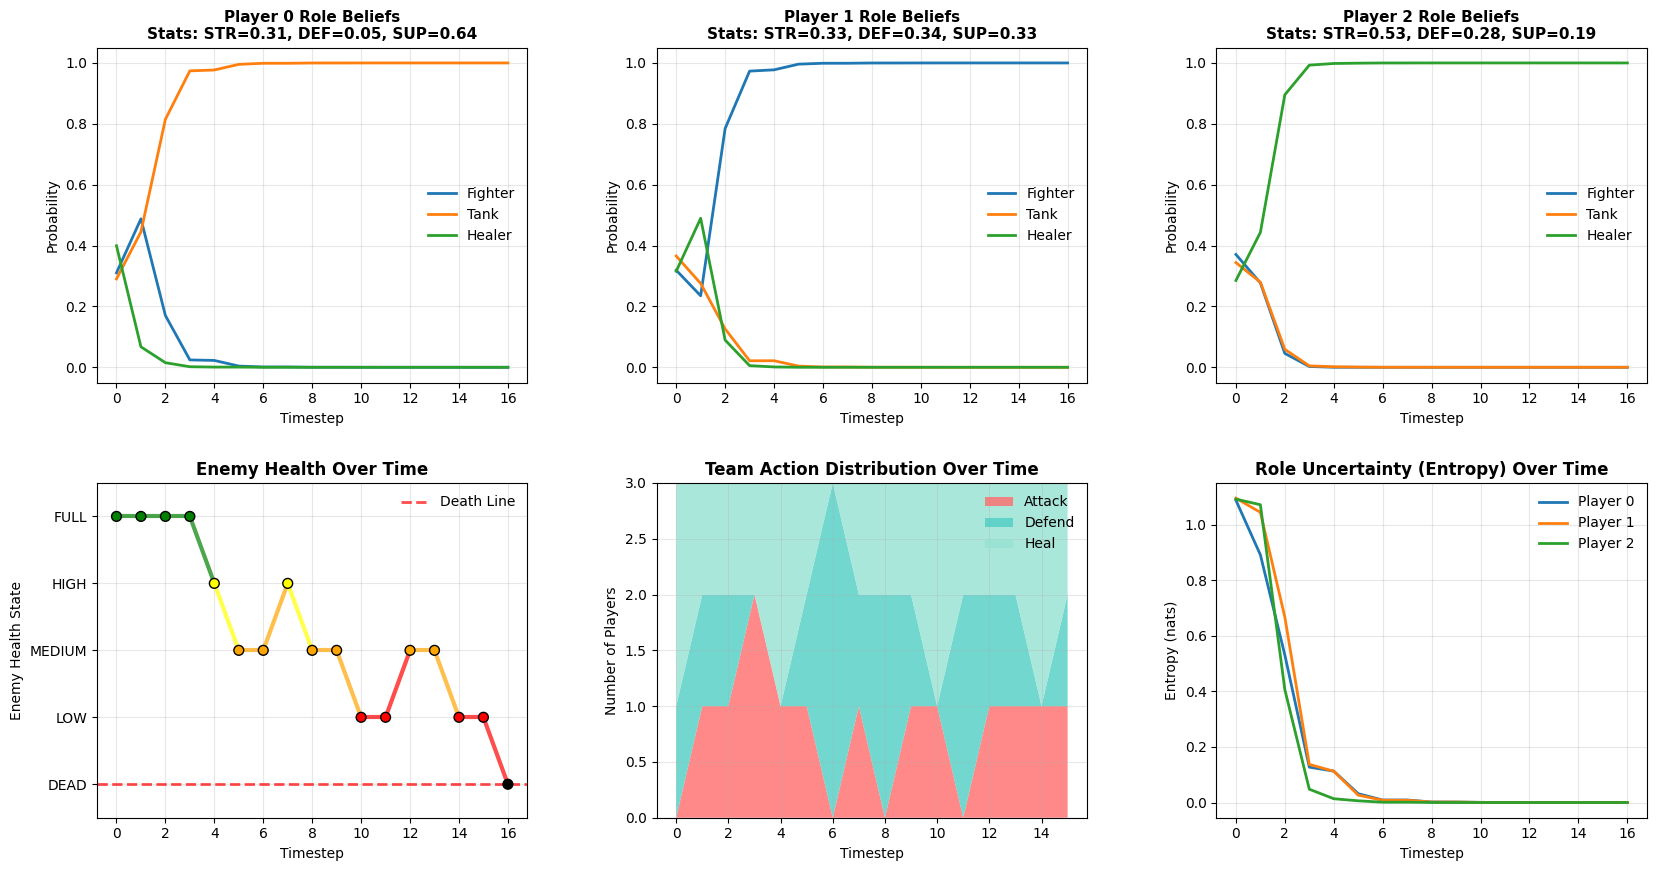


FINAL ROLE ASSIGNMENTS:
  Player 0: Tank
  Player 1: Fighter
  Player 2: Healer

ACTION DISTRIBUTION:
  Attacks: 13/48 (27.1%)
  Defends: 16/48 (33.3%)
  Heals: 19/48 (39.6%)

COORDINATION ANALYSIS:
  Stat-based best roles: ['Healer', 'Tank', 'Fighter']
  Final converged roles: ['Tank', 'Fighter', 'Healer']
  Role mismatches: 3/3
  Players adapted from their optimal roles for team coordination:
    Player 0: Healer -> Tank
    Player 1: Tank -> Fighter
    Player 2: Fighter -> Healer


In [99]:
# Run simulation
import time

max_steps = 100
temperature = 2.0  # Higher = more uncertainty in role prior

# Use current time for random seed - different every run!
seed = int(time.time() * 1000) % 100000

# Generate player stats
player_stats = [generate_player_stats(i, seed=seed) for i in range(3)]

print("PLAYER STATS")
for i, stats in enumerate(player_stats):
    print(f"Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}")
    best_role_idx = int(np.argmax(stats))
    best_role = Role(best_role_idx).name
    print(f"  -> Best suited for: {best_role} (utility={stats[best_role_idx]:.2f})")

role_history, action_history, role_prob_history, enemy_health_history, n_steps, victory, role_prior = simulate_role_convergence(
    max_steps, player_stats, initial_enemy_health=EnemyHealth.FULL, seed=seed, temperature=temperature
)

print(f"\nSimulation ran for {n_steps} action steps")
import matplotlib.pyplot as plt
import numpy as onp  # Use original numpy for non-JAX operations

# Create a figure with 4 subplots: 3 for role probabilities + 1 for enemy health
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Top row: Role probability evolution for each player
for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    
    # Calculate marginal probabilities for the current player at each timestep
    player_role_probs = [marginalize(role_prob_history[t], i) for t in range(n_steps)]
    # Add the initial timestep's probabilities
    player_role_probs.insert(0, marginalize(role_prior / role_prior.sum(), i))
    player_role_probs = onp.array(player_role_probs)

    # Plot the evolution of role probabilities for the current player
    for role in Role:
        ax.plot(range(n_steps + 1), player_role_probs[:, role], label=role.name, linewidth=2)

    # Add player stats to title
    stats = player_stats[i]
    title = f'Player {i} Role Beliefs\nStats: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}'
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Probability')
    ax.legend(frameon=False, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Bottom left: Enemy health over time
ax_health = fig.add_subplot(gs[1, 0])
health_names = ['DEAD', 'LOW', 'MEDIUM', 'HIGH', 'FULL']
health_colors = ['black', 'red', 'orange', 'yellow', 'green']
enemy_health_arr = onp.array(enemy_health_history)

# Plot with color coding
for i in range(len(enemy_health_arr) - 1):
    color = health_colors[int(enemy_health_arr[i])]
    ax_health.plot([i, i+1], [enemy_health_arr[i], enemy_health_arr[i+1]], 
                   color=color, linewidth=3, alpha=0.7)
    
ax_health.scatter(range(len(enemy_health_arr)), enemy_health_arr, 
                 c=[health_colors[int(h)] for h in enemy_health_arr], 
                 s=50, zorder=3, edgecolors='black', linewidth=1)
ax_health.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Death Line', alpha=0.7)
ax_health.set_title('Enemy Health Over Time', fontsize=12, fontweight='bold')
ax_health.set_xlabel('Timestep')
ax_health.set_ylabel('Enemy Health State')
ax_health.set_yticks(range(5))
ax_health.set_yticklabels(health_names)
ax_health.legend(frameon=False)
ax_health.grid(True, alpha=0.3)
ax_health.set_ylim([-0.5, 4.5])

# Bottom middle: Action distribution over time
ax_actions = fig.add_subplot(gs[1, 1])
action_counts = onp.zeros((n_steps, 3))
for t in range(n_steps):
    for a in action_history[t]:
        action_counts[t, int(a)] += 1

ax_actions.stackplot(range(n_steps), 
                     action_counts[:, 0], action_counts[:, 1], action_counts[:, 2],
                     labels=['Attack', 'Defend', 'Heal'],
                     colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
                     alpha=0.8)
ax_actions.set_title('Team Action Distribution Over Time', fontsize=12, fontweight='bold')
ax_actions.set_xlabel('Timestep')
ax_actions.set_ylabel('Number of Players')
ax_actions.legend(loc='upper right', frameon=False)
ax_actions.grid(True, alpha=0.3)
ax_actions.set_ylim([0, 3])

# Bottom right: Role entropy over time (measure of role uncertainty)
ax_entropy = fig.add_subplot(gs[1, 2])
from scipy.stats import entropy

role_entropy = onp.zeros((n_steps + 1, 3))
for i in range(3):
    # Initial entropy
    initial_marginal = marginalize(role_prior / role_prior.sum(), i)
    role_entropy[0, i] = entropy(onp.array(initial_marginal))
    
    # Entropy over time
    for t in range(n_steps):
        marginal = marginalize(role_prob_history[t], i)
        role_entropy[t + 1, i] = entropy(onp.array(marginal))

for i in range(3):
    ax_entropy.plot(range(n_steps + 1), role_entropy[:, i], label=f'Player {i}', linewidth=2)

ax_entropy.set_title('Role Uncertainty (Entropy) Over Time', fontsize=12, fontweight='bold')
ax_entropy.set_xlabel('Timestep')
ax_entropy.set_ylabel('Entropy (nats)')
ax_entropy.legend(frameon=False)
ax_entropy.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final statistics
final_enemy_health = int(enemy_health_history[-1])

if n_steps > 0:
    final_roles = [Role(onp.argmax(onp.array(marginalize(role_prob_history[-1], i)))).name for i in range(3)]
    
    # Calculate average action distribution
    total_attacks = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Attack])
    total_defends = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Defend])
    total_heals = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Heal])
    total_actions = total_attacks + total_defends + total_heals
    
    print(f"\nFINAL ROLE ASSIGNMENTS:")
    for i in range(3):
        print(f"  Player {i}: {final_roles[i]}")
    
    print(f"\nACTION DISTRIBUTION:")
    print(f"  Attacks: {total_attacks}/{total_actions} ({100*total_attacks/total_actions:.1f}%)")
    print(f"  Defends: {total_defends}/{total_actions} ({100*total_defends/total_actions:.1f}%)")
    print(f"  Heals: {total_heals}/{total_actions} ({100*total_heals/total_actions:.1f}%)")
    
    # Show coordination challenges
    best_roles = [Role(onp.argmax(player_stats[i])).name for i in range(3)]
    actual_roles = final_roles
    mismatches = sum(1 for i in range(3) if best_roles[i] != actual_roles[i])
    
    print(f"\nCOORDINATION ANALYSIS:")
    print(f"  Stat-based best roles: {best_roles}")
    print(f"  Final converged roles: {actual_roles}")
    print(f"  Role mismatches: {mismatches}/3")
    
    if mismatches > 0:
        print(f"  Players adapted from their optimal roles for team coordination:")
        for i in range(3):
            if best_roles[i] != actual_roles[i]:
                print(f"    Player {i}: {best_roles[i]} -> {actual_roles[i]}")


## 6. Enhanced Combat System

Extended game mechanics with two-sided battles where both the team and enemy have health pools. This creates more strategic depth as players must balance offense and defense.


In [ ]:
# ============================================================================
# ENHANCED COMBAT SYSTEM: Two-Sided Battle with Team Health
# ============================================================================


# Add TeamHealth state
class TeamHealth(IntEnum): 
    CRITICAL = 0  # Near death
    LOW = 1       # Damaged
    MEDIUM = 2    # Slightly hurt
    HIGH = 3      # Almost full
    FULL = 4      # Perfect health

# ENEMY ATTACK PROBABILITIES (REBALANCED - More threatening)
# Probability that enemy attacks (vs does nothing) depends on enemy health
# Healthier enemy = more aggressive
ENEMY_ATTACK_PROB = np.array([
    0.25,  # CRITICAL: 25% attack (very weak)
    0.40,  # LOW: 40% attack
    0.55,  # MEDIUM: 55% attack (buffed from 40%)
    0.65,  # HIGH: 65% attack (buffed from 50%)
    0.75,  # FULL: 75% attack (buffed from 50% - much more aggressive!)
])

# TEAM DAMAGE TRANSITION [num_defenders, damage_type]
# damage_type: 0 = lose health, 1 = stay same, 2 = gain health
# More defenders = better protection (SLIGHTLY NERFED - Defense is less perfect)
TEAM_DAMAGE_PROBS = np.array([
    [0.70, 0.25, 0.05],  # 0 defenders: 70% take damage (nerfed from 60%)
    [0.45, 0.40, 0.15],  # 1 defender: 45% take damage (nerfed from 35%)
    [0.25, 0.55, 0.20],  # 2 defenders: 25% take damage (nerfed from 15%)
    [0.10, 0.65, 0.25],  # 3 defenders: 10% take damage (nerfed from 5%)
])

# TEAM HEAL TRANSITION [num_healers, heal_type]
# heal_type: 0 = lose health, 1 = stay same, 2 = gain health
# More healers = better healing (SAME - healing is important)
TEAM_HEAL_PROBS = np.array([
    [0.0, 0.85, 0.15],   # 0 healers: 15% natural regen
    [0.0, 0.30, 0.70],   # 1 healer: 70% gain health
    [0.0, 0.15, 0.85],   # 2 healers: 85% gain health
    [0.0, 0.05, 0.95],   # 3 healers: 95% gain health
])

@jax.jit
def UpdateTeamHealth(current_team_health, enemy_health, num_defenders, num_healers, key):
    """
    Update team health based on enemy attack, defenders, and healers.
    
    Args:
        current_team_health: Current team health state (0=CRITICAL to 4=FULL)
        enemy_health: Current enemy health state (affects attack probability)
        num_defenders: Number of players defending (0-3)
        num_healers: Number of players healing (0-3)
        key: JAX random key
    
    Returns:
        next_team_health: Updated team health state
    
    Logic:
    1. Enemy attacks with probability based on enemy_health
    2. If attacked: damage depends on num_defenders
    3. Regardless: healing depends on num_healers
    4. Final health = current + damage_change + heal_change
    """
    
    key1, key2, key3 = jax.random.split(key, 3)
    
    # Clamp inputs
    num_defenders = np.clip(num_defenders, 0, 3)
    num_healers = np.clip(num_healers, 0, 3)
    
    # Step 1: Does enemy attack?
    enemy_attacks = jax.random.uniform(key1) < ENEMY_ATTACK_PROB[enemy_health]
    
    # Step 2: If attacked, calculate damage
    damage_change = jax.lax.cond(
        enemy_attacks,
        lambda: jax.random.choice(key2, np.array([-1, 0, 1]), p=TEAM_DAMAGE_PROBS[num_defenders]),
        lambda: 0  # No attack = no damage
    )
    
    # Step 3: Calculate healing (happens regardless of attack)
    heal_change = jax.random.choice(key3, np.array([-1, 0, 1]), p=TEAM_HEAL_PROBS[num_healers])
    
    # Step 4: Apply both changes
    total_change = damage_change + heal_change
    next_health = np.clip(current_team_health + total_change, 0, 4)
    
    return next_health

@jax.jit
def UpdateEnemyHealth(current_enemy_health, num_attackers, key):
    """
    Update enemy health based on number of attackers.
    (Same as before, but renamed for clarity)
    """
    num_attackers = np.clip(num_attackers, 0, 3)
    probs = TRANSITION_PROBS[num_attackers]
    change = jax.random.choice(key, np.array([-1, 0, 1]), p=probs)
    next_health = np.clip(current_enemy_health + change, 0, 4)
    return next_health




In [101]:
# ============================================================================
# ENHANCED SIMULATION WITH TWO-SIDED COMBAT
# ============================================================================

def simulate_enhanced_combat(n_steps, player_stats_list, 
                             initial_enemy_health=EnemyHealth.FULL,
                             initial_team_health=TeamHealth.FULL,
                             seed=42, temperature=1.0, allow_duplicates=False):
    """
    Simulate the role coordination game with TWO-SIDED combat.
    
    Victory conditions:
    - Win: Enemy reaches CRITICAL health
    - Lose: Team reaches CRITICAL health
    - Draw: Max steps reached
    
    Args:
        n_steps: Maximum timesteps
        player_stats_list: Player stats
        initial_enemy_health: Starting enemy health
        initial_team_health: Starting team health
        seed: Random seed
        temperature: Prior temperature
        allow_duplicates: Allow duplicate roles
    
    Returns:
        Tuple of (role_history, action_history, role_prob_history, 
                  enemy_health_history, team_health_history, 
                  actual_steps, victory_status, role_prior)
        victory_status: "WIN", "LOSE", or "DRAW"
    """
    random.seed(seed)
    key = jax.random.PRNGKey(seed)
    
    # Create prior
    role_prior = create_utility_based_prior(player_stats_list, temperature=temperature, 
                                            allow_duplicates=allow_duplicates)
    role_probs = role_prior
    enemy_health = initial_enemy_health
    team_health = initial_team_health
    
    # Preallocate arrays
    role_history = np.zeros((n_steps, 3), dtype=np.int32)
    action_history = np.zeros((n_steps, 3), dtype=np.int32)
    role_prob_history = np.zeros((n_steps, 3, 3, 3), dtype=np.float32)
    enemy_health_history = np.zeros(n_steps + 1, dtype=np.int32)
    team_health_history = np.zeros(n_steps + 1, dtype=np.int32)
    
    # Store initial health
    enemy_health_history = enemy_health_history.at[0].set(enemy_health)
    team_health_history = team_health_history.at[0].set(team_health)
    
    for t in range(n_steps):
        # Sample roles and actions
        roles = [random.choices([0, 1, 2], weights=marginalize(role_probs, i))[0] for i in range(3)]
        role_history = role_history.at[t].set(np.array(roles))
        
        actions = [random.choices([0, 1, 2], weights=ROLE_ACTION_STATE_PROBS[r, enemy_health, :])[0] for r in roles]
        action_history = action_history.at[t].set(np.array(actions))
        
        # Update role beliefs
        role_probs = role_inference(role_probs, *actions, enemy_health=enemy_health)
        role_prob_history = role_prob_history.at[t].set(role_probs)
        
        # Count action types
        num_attackers = sum(1 for a in actions if a == Action.Attack)
        num_defenders = sum(1 for a in actions if a == Action.Defend)
        num_healers = sum(1 for a in actions if a == Action.Heal)
        
        # Update both healths
        key, subkey1, subkey2 = jax.random.split(key, 3)
        enemy_health = UpdateEnemyHealth(enemy_health, num_attackers, subkey1)
        team_health = UpdateTeamHealth(team_health, enemy_health, num_defenders, num_healers, subkey2)
        
        # Store new health values
        enemy_health_history = enemy_health_history.at[t + 1].set(enemy_health)
        team_health_history = team_health_history.at[t + 1].set(team_health)
        
        # Check victory/defeat conditions
        if enemy_health == EnemyHealth.CRITICAL:
            actual_steps = t + 1
            victory_status = "WIN"
            break
        elif team_health == TeamHealth.CRITICAL:
            actual_steps = t + 1
            victory_status = "LOSE"
            break
    else:
        # Max steps reached
        actual_steps = n_steps
        victory_status = "DRAW"
    
    # Trim arrays
    role_history = role_history[:actual_steps]
    action_history = action_history[:actual_steps]
    role_prob_history = role_prob_history[:actual_steps]
    enemy_health_history = enemy_health_history[:actual_steps + 1]
    team_health_history = team_health_history[:actual_steps + 1]
    
    return (role_history, action_history, role_prob_history, 
            enemy_health_history, team_health_history, 
            actual_steps, victory_status, role_prior)




## 7. Visualizations and Results

### 7.1 Comparison: Unique vs Non-Unique Roles

Compare how role constraints (unique roles vs allowing duplicates) affect coordination.


In [102]:
# COMPARISON: Unique vs Non-Unique Roles

# Use the same player stats for fair comparison
test_stats = [generate_player_stats(i, seed=42) for i in range(3)]

for i, stats in enumerate(test_stats):
    print(f"Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}")

# Create both priors
unique_prior = create_utility_based_prior(test_stats, temperature=2.0, allow_duplicates=False)
nonunique_prior = create_utility_based_prior(test_stats, temperature=2.0, allow_duplicates=True)

flat_unique = []
for r0 in range(3):
    for r1 in range(3):
        for r2 in range(3):
            if unique_prior[r0, r1, r2] > 0:
                flat_unique.append(((r0, r1, r2), float(unique_prior[r0, r1, r2])))
flat_unique.sort(key=lambda x: x[1], reverse=True)
for (r0, r1, r2), prob in flat_unique[:5]:
    print(f"  ({Role(r0).name}, {Role(r1).name}, {Role(r2).name}): {prob:.4f}")

flat_nonunique = []
for r0 in range(3):
    for r1 in range(3):
        for r2 in range(3):
            if nonunique_prior[r0, r1, r2] > 0:
                flat_nonunique.append(((r0, r1, r2), float(nonunique_prior[r0, r1, r2])))
flat_nonunique.sort(key=lambda x: x[1], reverse=True)
for (r0, r1, r2), prob in flat_nonunique[:10]:
    duplicate_marker = " [DUPLICATE]" if (r0 == r1 or r0 == r2 or r1 == r2) else ""
    print(f"  ({Role(r0).name}, {Role(r1).name}, {Role(r2).name}): {prob:.4f}{duplicate_marker}")

# Test inference with same observation

test_actions = [Action.Attack, Action.Attack, Action.Defend]

# Run inference with both priors
unique_posterior = role_inference(unique_prior, *test_actions, enemy_health=EnemyHealth.FULL)
nonunique_posterior = role_inference(nonunique_prior, *test_actions, enemy_health=EnemyHealth.FULL)

flat_unique_post = []
for r0 in range(3):
    for r1 in range(3):
        for r2 in range(3):
            if unique_posterior[r0, r1, r2] > 0:
                flat_unique_post.append(((r0, r1, r2), float(unique_posterior[r0, r1, r2])))
flat_unique_post.sort(key=lambda x: x[1], reverse=True)
for (r0, r1, r2), prob in flat_unique_post[:3]:
    print(f"  ({Role(r0).name}, {Role(r1).name}, {Role(r2).name}): {prob:.4f}")

flat_nonunique_post = []
for r0 in range(3):
    for r1 in range(3):
        for r2 in range(3):
            if nonunique_posterior[r0, r1, r2] > 0:
                flat_nonunique_post.append(((r0, r1, r2), float(nonunique_posterior[r0, r1, r2])))
flat_nonunique_post.sort(key=lambda x: x[1], reverse=True)
for (r0, r1, r2), prob in flat_nonunique_post[:5]:
    duplicate_marker = " [DUPLICATE]" if (r0 == r1 or r0 == r2 or r1 == r2) else ""
    print(f"  ({Role(r0).name}, {Role(r1).name}, {Role(r2).name}): {prob:.4f}{duplicate_marker}")


Player 0: STR=0.75, DEF=0.02, SUP=0.24
Player 1: STR=0.03, DEF=0.86, SUP=0.11
Player 2: STR=0.16, DEF=0.24, SUP=0.60
  (Fighter, Tank, Healer): 0.2889
  (Healer, Tank, Fighter): 0.1793
  (Fighter, Healer, Tank): 0.1656
  (Tank, Fighter, Healer): 0.1325
  (Healer, Fighter, Tank): 0.1230
  (Fighter, Tank, Healer): 0.0655
  (Fighter, Tank, Tank): 0.0545 [DUPLICATE]
  (Fighter, Tank, Fighter): 0.0525 [DUPLICATE]
  (Healer, Tank, Healer): 0.0507 [DUPLICATE]
  (Tank, Tank, Healer): 0.0455 [DUPLICATE]
  (Fighter, Healer, Healer): 0.0450 [DUPLICATE]
  (Fighter, Fighter, Healer): 0.0432 [DUPLICATE]
  (Healer, Tank, Tank): 0.0422 [DUPLICATE]
  (Healer, Tank, Fighter): 0.0406
  (Tank, Tank, Tank): 0.0379 [DUPLICATE]
  (Fighter, Healer, Tank): 0.3617
  (Healer, Fighter, Tank): 0.2686
  (Fighter, Tank, Healer): 0.1941
  (Fighter, Fighter, Tank): 0.2451 [DUPLICATE]
  (Fighter, Fighter, Fighter): 0.1451 [DUPLICATE]
  (Fighter, Fighter, Healer): 0.0905 [DUPLICATE]
  (Fighter, Tank, Tank): 0.0825 [DUPL

### 7.2 Side-by-Side Visualization


  Player 0: STR=0.75, DEF=0.02, SUP=0.24
  Player 1: STR=0.03, DEF=0.86, SUP=0.11
  Player 2: STR=0.16, DEF=0.24, SUP=0.60


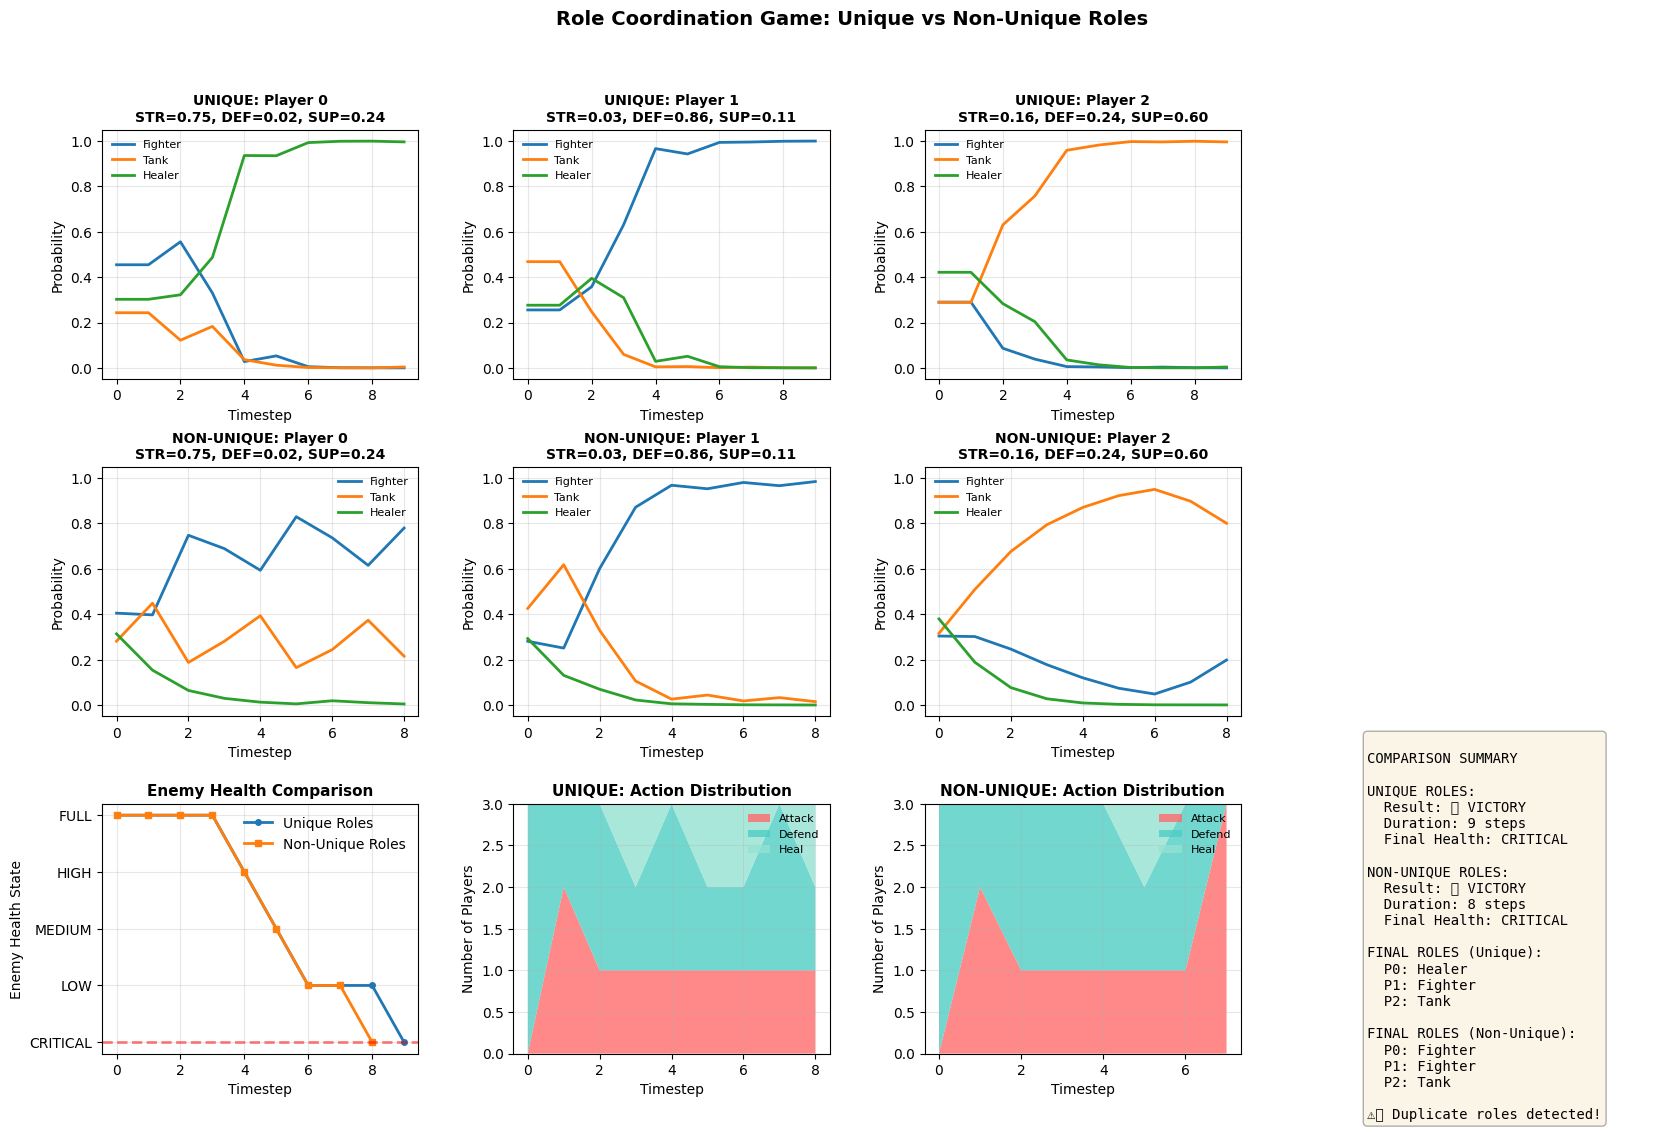

In [103]:
# SIDE-BY-SIDE SIMULATION: Unique vs Non-Unique Roles
import matplotlib.pyplot as plt
import numpy as onp


# Use same player stats and seed for both
comparison_seed = 42
comparison_stats = [generate_player_stats(i, seed=comparison_seed) for i in range(3)]

for i, stats in enumerate(comparison_stats):
    print(f"  Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}")

# Modify simulate_role_convergence to accept allow_duplicates parameter
def simulate_with_constraint(n_steps, player_stats_list, allow_duplicates, initial_enemy_health=EnemyHealth.FULL, 
                              seed=42, temperature=1.0):
    """Simulation with configurable role uniqueness constraint."""
    random.seed(seed)
    key = jax.random.PRNGKey(seed)
    
    # Create prior with or without uniqueness
    role_prior = create_utility_based_prior(player_stats_list, temperature=temperature, allow_duplicates=allow_duplicates)
    role_probs = role_prior
    enemy_health = initial_enemy_health
    
    role_history = np.zeros((n_steps, 3), dtype=np.int32)
    action_history = np.zeros((n_steps, 3), dtype=np.int32)
    role_prob_history = np.zeros((n_steps, 3, 3, 3), dtype=np.float32)
    enemy_health_history = np.zeros(n_steps + 1, dtype=np.int32)
    
    enemy_health_history = enemy_health_history.at[0].set(enemy_health)
    
    for t in range(n_steps):
        roles = [random.choices([0, 1, 2], weights=marginalize(role_probs, i))[0] for i in range(3)]
        role_history = role_history.at[t].set(np.array(roles))
        
        actions = [random.choices([0, 1, 2], weights=ROLE_ACTION_STATE_PROBS[r, enemy_health, :])[0] for r in roles]
        action_history = action_history.at[t].set(np.array(actions))
        
        role_probs = role_inference(role_probs, *actions, enemy_health=enemy_health)
        role_prob_history = role_prob_history.at[t].set(role_probs)
        
        num_attackers = sum(1 for a in actions if a == Action.Attack)
        
        key, subkey = jax.random.split(key)
        enemy_health = Transition(enemy_health, num_attackers, subkey)
        enemy_health_history = enemy_health_history.at[t + 1].set(enemy_health)
        
        if enemy_health == EnemyHealth.CRITICAL:
            actual_steps = t + 1
            victory = True
            break
    else:
        actual_steps = n_steps
        victory = False
    
    role_history = role_history[:actual_steps]
    action_history = action_history[:actual_steps]
    role_prob_history = role_prob_history[:actual_steps]
    enemy_health_history = enemy_health_history[:actual_steps + 1]
    
    return role_history, action_history, role_prob_history, enemy_health_history, actual_steps, victory, role_prior

# Run both simulations
max_steps = 100
temp = 2.0

unique_results = simulate_with_constraint(max_steps, comparison_stats, allow_duplicates=False, 
                                          seed=comparison_seed, temperature=temp)
unique_history, unique_actions, unique_probs, unique_health, unique_steps, unique_victory, unique_prior = unique_results

nonunique_results = simulate_with_constraint(max_steps, comparison_stats, allow_duplicates=True, 
                                             seed=comparison_seed, temperature=temp)
nonunique_history, nonunique_actions, nonunique_probs, nonunique_health, nonunique_steps, nonunique_victory, nonunique_prior = nonunique_results

# Create comparison visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

# Row 1: Role probabilities for UNIQUE constraint
for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    player_role_probs = [marginalize(unique_probs[t], i) for t in range(unique_steps)]
    player_role_probs.insert(0, marginalize(unique_prior / unique_prior.sum(), i))
    player_role_probs = onp.array(player_role_probs)
    
    for role in Role:
        ax.plot(range(unique_steps + 1), player_role_probs[:, role], label=role.name, linewidth=2)
    
    stats = comparison_stats[i]
    ax.set_title(f'UNIQUE: Player {i}\nSTR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}', 
                fontsize=10, fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Probability')
    ax.legend(frameon=False, loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Row 2: Role probabilities for NON-UNIQUE constraint
for i in range(3):
    ax = fig.add_subplot(gs[1, i])
    player_role_probs = [marginalize(nonunique_probs[t], i) for t in range(nonunique_steps)]
    player_role_probs.insert(0, marginalize(nonunique_prior / nonunique_prior.sum(), i))
    player_role_probs = onp.array(player_role_probs)
    
    for role in Role:
        ax.plot(range(nonunique_steps + 1), player_role_probs[:, role], label=role.name, linewidth=2)
    
    stats = comparison_stats[i]
    ax.set_title(f'NON-UNIQUE: Player {i}\nSTR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}', 
                fontsize=10, fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Probability')
    ax.legend(frameon=False, loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Row 3, Col 1: Enemy health comparison
ax = fig.add_subplot(gs[2, 0])
ax.plot(range(len(unique_health)), unique_health, label='Unique Roles', linewidth=2, marker='o', markersize=4)
ax.plot(range(len(nonunique_health)), nonunique_health, label='Non-Unique Roles', linewidth=2, marker='s', markersize=4)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax.set_title('Enemy Health Comparison', fontsize=11, fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Enemy Health State')
ax.set_yticks(range(5))
ax.set_yticklabels(['CRITICAL', 'LOW', 'MEDIUM', 'HIGH', 'FULL'])
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

# Row 3, Col 2: Action distribution comparison - UNIQUE
ax = fig.add_subplot(gs[2, 1])
action_counts_unique = onp.zeros((unique_steps, 3))
for t in range(unique_steps):
    for a in unique_actions[t]:
        action_counts_unique[t, int(a)] += 1
ax.stackplot(range(unique_steps), 
            action_counts_unique[:, 0], action_counts_unique[:, 1], action_counts_unique[:, 2],
            labels=['Attack', 'Defend', 'Heal'],
            colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
            alpha=0.8)
ax.set_title('UNIQUE: Action Distribution', fontsize=11, fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Number of Players')
ax.legend(loc='upper right', frameon=False, fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 3])

# Row 3, Col 3: Action distribution comparison - NON-UNIQUE
ax = fig.add_subplot(gs[2, 2])
action_counts_nonunique = onp.zeros((nonunique_steps, 3))
for t in range(nonunique_steps):
    for a in nonunique_actions[t]:
        action_counts_nonunique[t, int(a)] += 1
ax.stackplot(range(nonunique_steps), 
            action_counts_nonunique[:, 0], action_counts_nonunique[:, 1], action_counts_nonunique[:, 2],
            labels=['Attack', 'Defend', 'Heal'],
            colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
            alpha=0.8)
ax.set_title('NON-UNIQUE: Action Distribution', fontsize=11, fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Number of Players')
ax.legend(loc='upper right', frameon=False, fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 3])

# Row 3, Col 4: Summary statistics
ax = fig.add_subplot(gs[2, 3])
ax.axis('off')

summary_text = f"""
COMPARISON SUMMARY

UNIQUE ROLES:
  Result: {'🎉 VICTORY' if unique_victory else '💀 DEFEAT'}
  Duration: {unique_steps} steps
  Final Health: {EnemyHealth(int(unique_health[-1])).name}
  
NON-UNIQUE ROLES:
  Result: {'🎉 VICTORY' if nonunique_victory else '💀 DEFEAT'}
  Duration: {nonunique_steps} steps
  Final Health: {EnemyHealth(int(nonunique_health[-1])).name}

FINAL ROLES (Unique):
"""
unique_final = [Role(onp.argmax(onp.array(marginalize(unique_probs[-1], i)))).name for i in range(3)]
for i in range(3):
    summary_text += f"  P{i}: {unique_final[i]}\n"

summary_text += f"\nFINAL ROLES (Non-Unique):\n"
nonunique_final = [Role(onp.argmax(onp.array(marginalize(nonunique_probs[-1], i)))).name for i in range(3)]
for i in range(3):
    summary_text += f"  P{i}: {nonunique_final[i]}\n"

# Check for duplicates
nonunique_has_dups = len(nonunique_final) != len(set(nonunique_final))
if nonunique_has_dups:
    summary_text += "\n⚠️ Duplicate roles detected!"

ax.text(0.1, 0.5, summary_text, fontsize=10, family='monospace', 
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Role Coordination Game: Unique vs Non-Unique Roles', 
            fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()




### 7.3 Enhanced Combat Comparison


PLAYER STATS:
  Player 0: STR=0.49, DEF=0.23, SUP=0.28
  Player 1: STR=0.15, DEF=0.05, SUP=0.79
  Player 2: STR=0.39, DEF=0.29, SUP=0.32


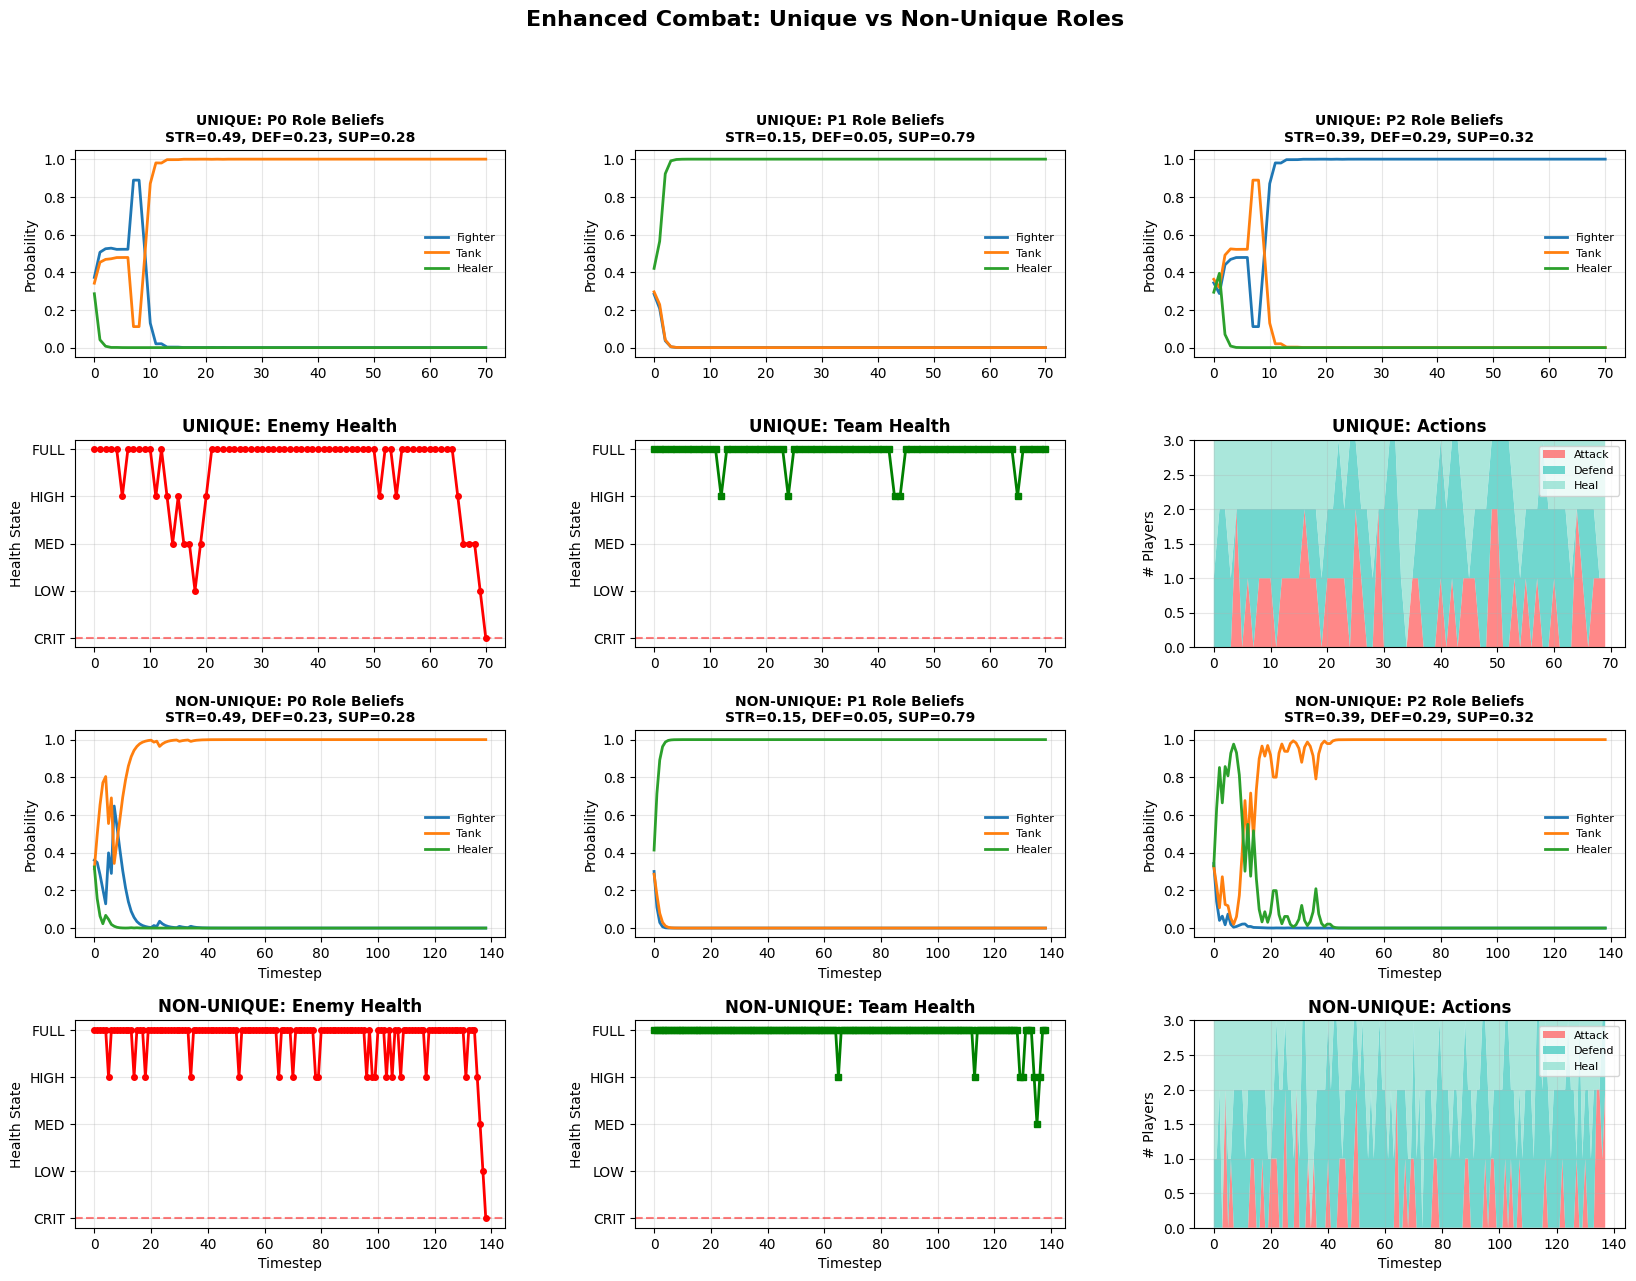


COMPARISON SUMMARY

UNIQUE ROLES:
  Result: WIN
  Duration: 70 steps
  Final Enemy Health: CRITICAL
  Final Team Health: FULL
  Final Roles: ['Tank', 'Healer', 'Fighter']
  Action Distribution:
    Attack: 44/210 (21.0%)
    Defend: 96/210 (45.7%)
    Heal: 70/210 (33.3%)

NON-UNIQUE ROLES:
  Result: WIN
  Duration: 138 steps
  Final Enemy Health: CRITICAL
  Final Team Health: FULL
  Final Roles: ['Tank', 'Healer', 'Tank']
  Action Distribution:
    Attack: 48/414 (11.6%)
    Defend: 216/414 (52.2%)
    Heal: 150/414 (36.2%)

OVERALL COMPARISON:
  UNIQUE roles performed better (both won with same health, but UNIQUE was faster: 70 vs 138 steps)


In [104]:
# ============================================================================
# TEST: Compare "All Fighters" vs "Balanced Team" with new combat system
# ============================================================================

import time
import matplotlib.pyplot as plt
import numpy as onp

# Generate test player stats - random seed each time!
test_seed = int(time.time() * 1000) % 100000
test_stats = [generate_player_stats(i, seed=test_seed) for i in range(3)]

print("PLAYER STATS:")
for i, stats in enumerate(test_stats):
    print(f"  Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}")

result_unique = simulate_enhanced_combat(
    n_steps=200,
    player_stats_list=test_stats,
    seed=test_seed,
    temperature=2.0,
    allow_duplicates=False  # Forces Fighter, Tank, Healer
)
role_hist_u, action_hist_u, role_probs_u, enemy_hp_u, team_hp_u, steps_u, status_u, prior_u = result_unique

result_nonunique = simulate_enhanced_combat(
    n_steps=200,
    player_stats_list=test_stats,
    seed=test_seed,
    temperature=2.0,
    allow_duplicates=True  # Allows duplicate roles
)
role_hist_nu, action_hist_nu, role_probs_nu, enemy_hp_nu, team_hp_nu, steps_nu, status_nu, prior_nu = result_nonunique

# Visualize comparison with role probabilities
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)
fig.suptitle('Enhanced Combat: Unique vs Non-Unique Roles', fontsize=16, fontweight='bold')

# Row 1: Role probabilities for UNIQUE constraint (3 players)
for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    player_role_probs = [marginalize(role_probs_u[t], i) for t in range(steps_u)]
    player_role_probs.insert(0, marginalize(prior_u / prior_u.sum(), i))
    player_role_probs = onp.array(player_role_probs)

    for role in Role:
        ax.plot(range(steps_u + 1), player_role_probs[:, role], label=role.name, linewidth=2)

    stats = test_stats[i]
    ax.set_title(f'UNIQUE: P{i} Role Beliefs\nSTR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}',
                fontsize=10, fontweight='bold')
    ax.set_ylabel('Probability')
    ax.legend(frameon=False, loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Row 2: Health bars for UNIQUE
# Enemy health
ax = fig.add_subplot(gs[1, 0])
ax.plot(range(len(enemy_hp_u)), enemy_hp_u, 'r-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('UNIQUE: Enemy Health', fontweight='bold')
ax.set_ylabel('Health State')
ax.set_yticks(range(5))
ax.set_yticklabels(['CRIT', 'LOW', 'MED', 'HIGH', 'FULL'])
ax.grid(True, alpha=0.3)

# Team health
ax = fig.add_subplot(gs[1, 1])
ax.plot(range(len(team_hp_u)), team_hp_u, 'g-', linewidth=2, marker='s', markersize=4)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('UNIQUE: Team Health', fontweight='bold')
ax.set_ylabel('Health State')
ax.set_yticks(range(5))
ax.set_yticklabels(['CRIT', 'LOW', 'MED', 'HIGH', 'FULL'])
ax.grid(True, alpha=0.3)

# Action distribution
ax = fig.add_subplot(gs[1, 2])
action_counts_u = onp.zeros((steps_u, 3))
for t in range(steps_u):
    for a in action_hist_u[t]:
        action_counts_u[t, int(a)] += 1
ax.stackplot(range(steps_u),
             action_counts_u[:, 0], action_counts_u[:, 1], action_counts_u[:, 2],
             labels=['Attack', 'Defend', 'Heal'],
             colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
             alpha=0.8)
ax.set_title('UNIQUE: Actions', fontweight='bold')
ax.set_ylabel('# Players')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim([0, 3])
ax.grid(True, alpha=0.3)

# Row 3: Role probabilities for NON-UNIQUE constraint (3 players)
for i in range(3):
    ax = fig.add_subplot(gs[2, i])
    player_role_probs = [marginalize(role_probs_nu[t], i) for t in range(steps_nu)]
    player_role_probs.insert(0, marginalize(prior_nu / prior_nu.sum(), i))
    player_role_probs = onp.array(player_role_probs)

    for role in Role:
        ax.plot(range(steps_nu + 1), player_role_probs[:, role], label=role.name, linewidth=2)

    stats = test_stats[i]
    ax.set_title(f'NON-UNIQUE: P{i} Role Beliefs\nSTR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}',
                fontsize=10, fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Probability')
    ax.legend(frameon=False, loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Row 4: Health bars for NON-UNIQUE
# Enemy health
ax = fig.add_subplot(gs[3, 0])
ax.plot(range(len(enemy_hp_nu)), enemy_hp_nu, 'r-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('NON-UNIQUE: Enemy Health', fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Health State')
ax.set_yticks(range(5))
ax.set_yticklabels(['CRIT', 'LOW', 'MED', 'HIGH', 'FULL'])
ax.grid(True, alpha=0.3)

# Team health
ax = fig.add_subplot(gs[3, 1])
ax.plot(range(len(team_hp_nu)), team_hp_nu, 'g-', linewidth=2, marker='s', markersize=4)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('NON-UNIQUE: Team Health', fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Health State')
ax.set_yticks(range(5))
ax.set_yticklabels(['CRIT', 'LOW', 'MED', 'HIGH', 'FULL'])
ax.grid(True, alpha=0.3)

# Action distribution
ax = fig.add_subplot(gs[3, 2])
action_counts_nu = onp.zeros((steps_nu, 3))
for t in range(steps_nu):
    for a in action_hist_nu[t]:
        action_counts_nu[t, int(a)] += 1
ax.stackplot(range(steps_nu),
             action_counts_nu[:, 0], action_counts_nu[:, 1], action_counts_nu[:, 2],
             labels=['Attack', 'Defend', 'Heal'],
             colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
             alpha=0.8)
ax.set_title('NON-UNIQUE: Actions', fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('# Players')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim([0, 3])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)

# Show final roles for UNIQUE
print("\nUNIQUE ROLES:")
print(f"  Result: {status_u}")
print(f"  Duration: {steps_u} steps")
print(f"  Final Enemy Health: {EnemyHealth(int(enemy_hp_u[-1])).name}")
print(f"  Final Team Health: {TeamHealth(int(team_hp_u[-1])).name}")
unique_final = [Role(onp.argmax(onp.array(marginalize(role_probs_u[-1], i)))).name for i in range(3)]
print(f"  Final Roles: {unique_final}")

total_u = onp.sum(action_counts_u, axis=0)
total_actions_u = total_u.sum()
print(f"  Action Distribution:")
print(f"    Attack: {int(total_u[0])}/{int(total_actions_u)} ({100*total_u[0]/total_actions_u:.1f}%)")
print(f"    Defend: {int(total_u[1])}/{int(total_actions_u)} ({100*total_u[1]/total_actions_u:.1f}%)")
print(f"    Heal: {int(total_u[2])}/{int(total_actions_u)} ({100*total_u[2]/total_actions_u:.1f}%)")

# Show final roles for NON-UNIQUE and check for duplicates
print("\nNON-UNIQUE ROLES:")
print(f"  Result: {status_nu}")
print(f"  Duration: {steps_nu} steps")
print(f"  Final Enemy Health: {EnemyHealth(int(enemy_hp_nu[-1])).name}")
print(f"  Final Team Health: {TeamHealth(int(team_hp_nu[-1])).name}")
nonunique_final = [Role(onp.argmax(onp.array(marginalize(role_probs_nu[-1], i)))).name for i in range(3)]
print(f"  Final Roles: {nonunique_final}")

nonunique_has_dups = len(nonunique_final) != len(set(nonunique_final))
if nonunique_has_dups:
    print(f"  WARNING: Duplicate roles detected!")

total_nu = onp.sum(action_counts_nu, axis=0)
total_actions_nu = total_nu.sum()
print(f"  Action Distribution:")
print(f"    Attack: {int(total_nu[0])}/{int(total_actions_nu)} ({100*total_nu[0]/total_actions_nu:.1f}%)")
print(f"    Defend: {int(total_nu[1])}/{int(total_actions_nu)} ({100*total_nu[1]/total_actions_nu:.1f}%)")
print(f"    Heal: {int(total_nu[2])}/{int(total_actions_nu)} ({100*total_nu[2]/total_actions_nu:.1f}%)")

# Overall comparison
print("\nOVERALL COMPARISON:")
if status_u == "WIN" and status_nu == "LOSE":
    print("  UNIQUE roles performed better (WIN vs LOSE)")
elif status_u == "WIN" and status_nu == "WIN":
    if team_hp_u[-1] > team_hp_nu[-1]:
        print(f"  UNIQUE roles performed better (both won, but UNIQUE had higher team health: {int(team_hp_u[-1])} vs {int(team_hp_nu[-1])})")
    elif team_hp_u[-1] < team_hp_nu[-1]:
        print(f"  NON-UNIQUE roles performed better (both won, but NON-UNIQUE had higher team health: {int(team_hp_nu[-1])} vs {int(team_hp_u[-1])})")
    elif steps_u < steps_nu:
        print(f"  UNIQUE roles performed better (both won with same health, but UNIQUE was faster: {steps_u} vs {steps_nu} steps)")
    elif steps_nu < steps_u:
        print(f"  NON-UNIQUE roles performed better (both won with same health, but NON-UNIQUE was faster: {steps_nu} vs {steps_u} steps)")
    else:
        print("  Both strategies performed equally well")
elif status_u == "LOSE" and status_nu == "WIN":
    print("  NON-UNIQUE roles performed better (WIN vs LOSE)")
else:
    print(f"  Both strategies resulted in {status_u}")
    if team_hp_u[-1] > team_hp_nu[-1]:
        print(f"    UNIQUE had higher team health: {int(team_hp_u[-1])} vs {int(team_hp_nu[-1])}")
    elif team_hp_nu[-1] > team_hp_u[-1]:
        print(f"    NON-UNIQUE had higher team health: {int(team_hp_nu[-1])} vs {int(team_hp_u[-1])}")